# Capstone Session 10

This notebook is generated from the copied `Capstone_Session_10.pdf` directions and the staged extracted image folders under `data/`.

## Objective

Build and compare transfer-learning classifiers for Session 10 (Task A: EfficientNetB0, Task B: ResNet50, Task C: best-model comparison and prediction evidence) following the copied PDF requirements.

PDF class values for this task are: `with_mask`, `without_mask`, and `mask_worn_incorrect`.

## Source Governance Note

The PDF directions remain the source of truth for capstone objectives, model tasks, and deliverables. Dataset inputs follow the project workflow rule from `Project_DEV_Rules_PROMPT.md`: approved GitHub-backed dataset files are the source of truth for notebook inputs.

When the staged dataset does not include every PDF-expected class folder (for example `mask_weared_incorrect`), the notebook records the gap explicitly and executes with the classes that are actually present in the GitHub-backed source.

## Runtime Scope Note

The copied PDF expects pre-made `train/` and `test/` folders. The staged GitHub-backed source for this capstone is an archive/extracted class-folder layout under `data/`, so this notebook generates runtime `train/` and `test/` folders before modeling.

To keep transfer-learning runs executable on the current CPU-only Windows environment, a fixed stratified subset is used for generated splits and all outputs are saved under `outputs/`.

In [24]:
print('Kernel probe: cell 5 started')
probe_value = 2 + 2
print('Kernel probe: cell 5 completed, value =', probe_value)

Kernel probe: cell 5 started
Kernel probe: cell 5 completed, value = 4


In [25]:
import json
print('Import OK: json')

Import OK: json


In [26]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print('Import OK: os and TF log level set')

Import OK: os and TF log level set


In [27]:
import random
random.seed(42)
print('Import OK: random (seed=42)')

Import OK: random (seed=42)


In [28]:
import shutil
print('Import OK: shutil')

Import OK: shutil


In [29]:
import subprocess
print('Import OK: subprocess')

Import OK: subprocess


In [30]:
import sys
print('Import OK: sys', sys.version.split()[0])

Import OK: sys 3.12.10


In [31]:
import matplotlib.pyplot as plt
print('Import OK: matplotlib')

Import OK: matplotlib


In [32]:
import numpy as np
print('Import OK: numpy', np.__version__)

Import OK: numpy 1.26.4


In [33]:
import pandas as pd
print('Import OK: pandas', pd.__version__)

Import OK: pandas 3.0.3


In [34]:
import seaborn as sns
sns.set_theme(style='whitegrid')
print('Import OK: seaborn')

Import OK: seaborn


In [35]:
import tensorflow as tf
tf.keras.utils.set_random_seed(42)
print('Import OK: tensorflow', tf.__version__)

Import OK: tensorflow 2.21.0


In [ ]:
from pathlib import Path

IS_COLAB = 'google.colab' in sys.modules
GITHUB_REPO_OWNER = 'FrancisBurnet'
GITHUB_REPO_NAME = 'francisburnet'
GITHUB_REPO_BRANCH = 'main'
GITHUB_REPO_URL = f'https://github.com/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}.git'
CAPSTONE_ROOT = Path('Incremental Capstones/Deep Learning Specialization/Capstone Session 10')
PDF_EXPECTED_CLASSES = ['with_mask', 'without_mask', 'mask_worn_incorrect']
PDF_CLASS_ALIASES = {
    'mask_worn_incorrect': {'mask_worn_incorrect', 'mask_weared_incorrect'},
}


def resolve_capstone_dir() -> Path | None:
    current = Path.cwd().resolve()
    capstone_parts = CAPSTONE_ROOT.parts
    for candidate in [current, *current.parents]:
        if len(candidate.parts) >= len(capstone_parts) and candidate.parts[-len(capstone_parts):] == capstone_parts:
            return candidate
        nested_candidate = candidate / CAPSTONE_ROOT
        if nested_candidate.exists():
            return nested_candidate
    return None


def ensure_colab_capstone_dir() -> Path:
    repo_root = Path('/content') / GITHUB_REPO_NAME
    capstone_dir = repo_root / CAPSTONE_ROOT
    data_dir = capstone_dir / 'data'

    if not repo_root.exists():
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', GITHUB_REPO_BRANCH, GITHUB_REPO_URL, str(repo_root)], check=True)

    has_lfs = subprocess.run(['bash', '-lc', 'command -v git-lfs >/dev/null 2>&1'], check=False).returncode == 0
    if not has_lfs:
        subprocess.run(['apt-get', 'update', '-qq'], check=True)
        subprocess.run(['apt-get', 'install', '-y', 'git-lfs'], check=True)

    subprocess.run(['git', 'lfs', 'install', '--local'], cwd=repo_root, check=True)
    subprocess.run(['git', 'lfs', 'pull', '--include', f'{CAPSTONE_ROOT.as_posix()}/data/**'], cwd=repo_root, check=True)

    if not data_dir.exists():
        raise RuntimeError(f'Expected GitHub-backed data directory at {data_dir}, but it was not found after clone + LFS pull.')

    # Verify actual image content was pulled — LFS pointer stubs are <200 bytes
    image_files = [f for f in data_dir.rglob('*') if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    if not image_files:
        raise RuntimeError(f'No image files found under {data_dir} — LFS pull may not have downloaded content.')
    tiny = [f for f in image_files[:10] if f.stat().st_size < 1000]
    if tiny:
        raise RuntimeError(
            f'LFS pointer file detected — actual image content was not downloaded.\n'
            f'File: {tiny[0]} ({tiny[0].stat().st_size} bytes)\n'
            f'Fix: run `git lfs pull` inside {repo_root}'
        )
    print(f'LFS verified: {len(image_files)} image files found under data/')

    return capstone_dir


if IS_COLAB:
    CAPSTONE_DIR = ensure_colab_capstone_dir()
else:
    CAPSTONE_DIR = resolve_capstone_dir()

if CAPSTONE_DIR is None:
    raise RuntimeError(f'Could not resolve capstone directory from {CAPSTONE_ROOT}')

OUTPUT_ROOT = CAPSTONE_DIR
OUTPUT_MODE = 'permanent capstone outputs'
OUTPUT_DISPLAY = (CAPSTONE_ROOT / 'outputs').as_posix()

SOURCE_DATA_DIR = CAPSTONE_DIR / 'data'
if not SOURCE_DATA_DIR.exists():
    raise RuntimeError(f'Expected staged dataset at {SOURCE_DATA_DIR}, but it does not exist.')

AVAILABLE_CLASS_FOLDERS = sorted([path.name for path in SOURCE_DATA_DIR.iterdir() if path.is_dir()])
if len(AVAILABLE_CLASS_FOLDERS) < 2:
    raise RuntimeError(f'Expected at least two class folders under {SOURCE_DATA_DIR}, found {AVAILABLE_CLASS_FOLDERS}.')

CLASS_NAME_LOOKUP = {}
for expected_name in PDF_EXPECTED_CLASSES:
    alias_set = PDF_CLASS_ALIASES.get(expected_name, {expected_name})
    for candidate_name in AVAILABLE_CLASS_FOLDERS:
        if candidate_name in alias_set:
            CLASS_NAME_LOOKUP[expected_name] = candidate_name
            break

ordered_classes = [CLASS_NAME_LOOKUP[name] for name in PDF_EXPECTED_CLASSES if name in CLASS_NAME_LOOKUP]
remaining_classes = [name for name in AVAILABLE_CLASS_FOLDERS if name not in ordered_classes]
CLASS_NAMES = ordered_classes + remaining_classes
NUM_CLASSES = len(CLASS_NAMES)
MISSING_PDF_CLASSES = [name for name in PDF_EXPECTED_CLASSES if name not in CLASS_NAME_LOOKUP]

OUTPUTS_DIR = (OUTPUT_ROOT / 'outputs').resolve()
PLOTS_DIR = OUTPUTS_DIR / 'plots'
GENERATED_SPLIT_DIR = OUTPUTS_DIR / 'generated_split'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
TRAIN_IMAGES_PER_CLASS = 120
TEST_IMAGES_PER_CLASS = 30

print('Runtime:', 'Google Colab' if IS_COLAB else 'Notebook runtime')
print('GitHub source repo:', f'https://github.com/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}/tree/{GITHUB_REPO_BRANCH}')
print('Capstone artifact path:', CAPSTONE_ROOT.as_posix())
print('Source data (GitHub-backed):', f'{CAPSTONE_ROOT.as_posix()}/data')
print('Output mode:', OUTPUT_MODE)
print('Output target:', OUTPUT_DISPLAY)
print('PDF expected classes:', PDF_EXPECTED_CLASSES)
print('Available source classes:', AVAILABLE_CLASS_FOLDERS)
print('Missing PDF classes from source:', MISSING_PDF_CLASSES if MISSING_PDF_CLASSES else 'None')
print('Classes used for this run:', CLASS_NAMES)


Runtime: Notebook runtime
GitHub source repo: https://github.com/FrancisBurnet/francisburnet/tree/main
Capstone artifact path: Incremental Capstones/Deep Learning Specialization/Capstone Session 10
Source data (GitHub-backed): Incremental Capstones/Deep Learning Specialization/Capstone Session 10/data
Output mode: permanent capstone outputs
Output target: Incremental Capstones/Deep Learning Specialization/Capstone Session 10/outputs
PDF expected classes: ['with_mask', 'without_mask', 'mask_worn_incorrect']
Available source classes: ['mask_worn_incorrect', 'with_mask', 'without_mask']
Missing PDF classes from source: None
Classes used for this run: ['with_mask', 'without_mask', 'mask_worn_incorrect']


In [ ]:
# Clear any previous generated split so re-runs start clean
if GENERATED_SPLIT_DIR.exists():
    shutil.rmtree(GENERATED_SPLIT_DIR)

split_manifest = {'source_counts': {}, 'generated_counts': {}}
for split_name in ['train', 'test']:
    for class_name in CLASS_NAMES:
        (GENERATED_SPLIT_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)

for class_name in CLASS_NAMES:
    source_files = sorted([path for path in (SOURCE_DATA_DIR / class_name).iterdir() if path.is_file()])
    split_manifest['source_counts'][class_name] = len(source_files)
    random.shuffle(source_files)
    train_files = source_files[:TRAIN_IMAGES_PER_CLASS]
    test_files = source_files[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + TEST_IMAGES_PER_CLASS]
    split_manifest['generated_counts'][class_name] = {'train': len(train_files), 'test': len(test_files)}
    for file_path in train_files:
        shutil.copy2(file_path, GENERATED_SPLIT_DIR / 'train' / class_name / file_path.name)
    for file_path in test_files:
        shutil.copy2(file_path, GENERATED_SPLIT_DIR / 'test' / class_name / file_path.name)

with open(OUTPUTS_DIR / 'session_10_split_manifest.json', 'w', encoding='utf-8') as handle:
    json.dump(split_manifest, handle, indent=2)
split_manifest


{'source_counts': {'with_mask': 3725,
  'without_mask': 3828,
  'mask_worn_incorrect': 1815},
 'generated_counts': {'with_mask': {'train': 120, 'test': 30},
  'without_mask': {'train': 120, 'test': 30},
  'mask_worn_incorrect': {'train': 120, 'test': 30}}}

In [38]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.08,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode='nearest',
)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    GENERATED_SPLIT_DIR / 'train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)
validation_generator = train_datagen.flow_from_directory(
    GENERATED_SPLIT_DIR / 'train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)
test_generator = test_datagen.flow_from_directory(
    GENERATED_SPLIT_DIR / 'test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
class_indices = train_generator.class_indices
class_labels = {index: label for label, index in class_indices.items()}
class_indices

Found 288 images belonging to 3 classes.
Found 72 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


{'mask_worn_incorrect': 0, 'with_mask': 1, 'without_mask': 2}

In [39]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
]
PRETRAIN_EPOCHS = 15
FINE_TUNE_LR = 1e-5

def build_transfer_model(base_model_name):
    if base_model_name == 'EfficientNetB0':
        preprocess = tf.keras.applications.efficientnet.preprocess_input
        base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
        dropout_rate = 0.2
        fine_tune_at = max(0, len(base_model.layers) - 40)
    elif base_model_name == 'ResNet50':
        preprocess = tf.keras.applications.resnet50.preprocess_input
        base_model = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
        dropout_rate = 0.5
        fine_tune_at = max(0, len(base_model.layers) - 30)
    else:
        raise ValueError(base_model_name)

    base_model.trainable = False
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),
        tf.keras.layers.Lambda(preprocess),
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model._capstone_fine_tune_at = fine_tune_at
    return model

def fine_tune_model(model, base_model_name):
    base_model = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model))
    fine_tune_at = getattr(model, '_capstone_fine_tune_at', max(0, len(base_model.layers) - 30))
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    for layer in base_model.layers[fine_tune_at:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

In [40]:
histories = {}
evaluations = []
prediction_examples = {}
for model_name in ['EfficientNetB0', 'ResNet50']:
    tf.keras.backend.clear_session()
    train_generator.reset()
    validation_generator.reset()
    test_generator.reset()
    model = build_transfer_model(model_name)
    frozen_history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=PRETRAIN_EPOCHS,
        callbacks=callbacks,
        verbose=0,
    )
    model = fine_tune_model(model, model_name)
    fine_tune_history = model.fit(
        train_generator,
        validation_data=validation_generator,
        initial_epoch=len(frozen_history.history['loss']),
        epochs=25,
        callbacks=callbacks,
        verbose=0,
    )
    histories[model_name] = pd.concat([
        pd.DataFrame(frozen_history.history),
        pd.DataFrame(fine_tune_history.history),
    ], ignore_index=True)
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
    test_generator.reset()
    probabilities = model.predict(test_generator, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)
    true_labels = test_generator.classes.copy()
    evaluations.append({
        'model': model_name,
        'epochs_ran': int(len(histories[model_name])),
        'test_loss': float(test_loss),
        'test_accuracy': float(test_accuracy),
    })
    prediction_examples[model_name] = {
        'filenames': test_generator.filenames[:10],
        'true_labels': [class_labels[index] for index in true_labels[:10]],
        'predicted_labels': [class_labels[index] for index in predicted_labels[:10]],
    }
evaluations_df = pd.DataFrame(evaluations).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
evaluations_df

,model,epochs_ran,test_loss,test_accuracy
0,ResNet50,24,0.766586,0.655556
1,EfficientNetB0,15,1.097273,0.333333


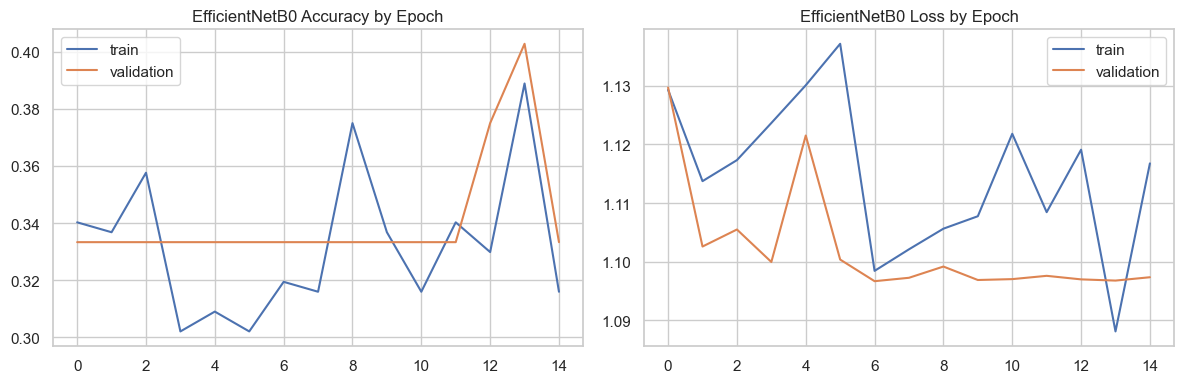

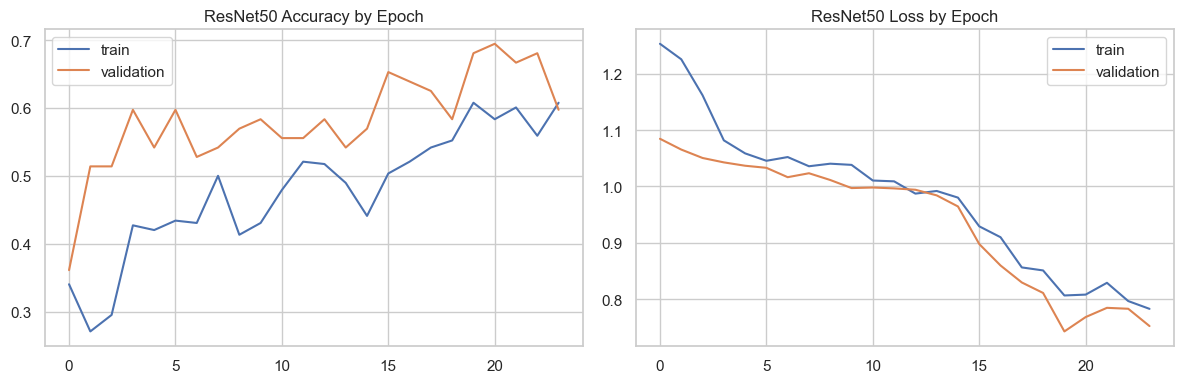

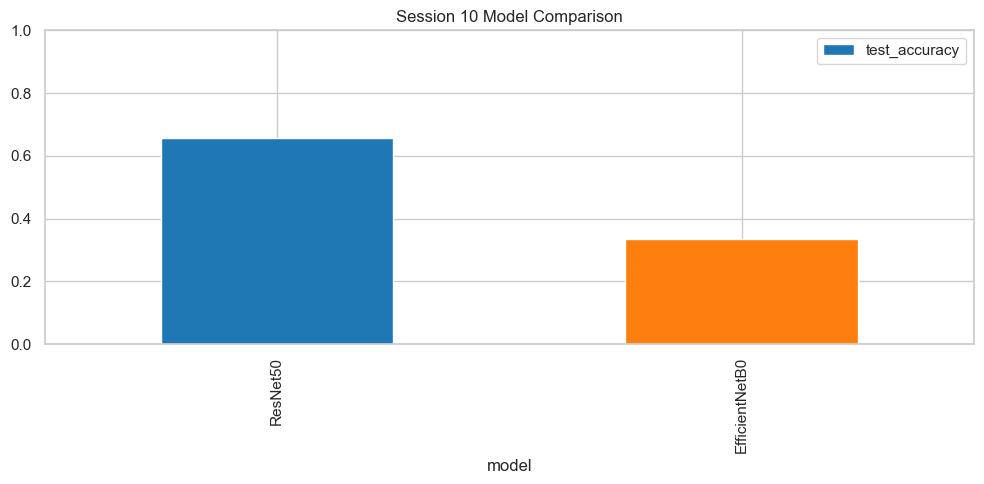

In [41]:
for model_name, history_df in histories.items():
    history_df.to_csv(OUTPUTS_DIR / f'{model_name.lower()}_history.csv', index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['accuracy'], label='train')
    axes[0].plot(history_df['val_accuracy'], label='validation')
    axes[0].set_title(f'{model_name} Accuracy by Epoch')
    axes[0].legend()
    axes[1].plot(history_df['loss'], label='train')
    axes[1].plot(history_df['val_loss'], label='validation')
    axes[1].set_title(f'{model_name} Loss by Epoch')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f'{model_name.lower()}_training_history.png', dpi=150)
    plt.show()
    plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
evaluations_df.plot(x='model', y='test_accuracy', kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Session 10 Model Comparison')
ax.set_ylim(0, 1.0)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'model_comparison.png', dpi=150)
plt.show()
plt.close(fig)

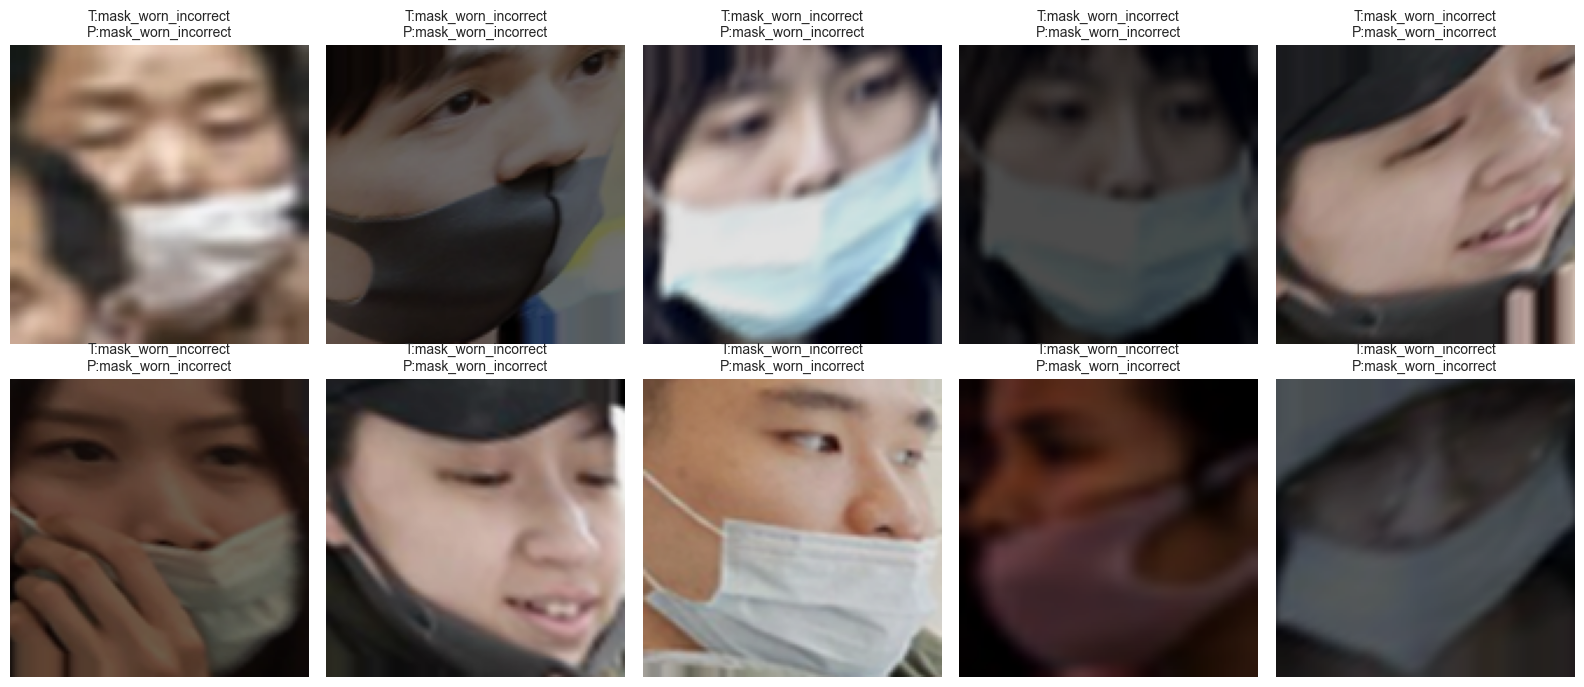

In [42]:
best_model_name = evaluations_df.iloc[0]['model']
example_info = prediction_examples[best_model_name]
figure, axes = plt.subplots(2, 5, figsize=(16, 7))
for axis, filename, true_label, predicted_label in zip(axes.flatten(), example_info['filenames'], example_info['true_labels'], example_info['predicted_labels']):
    image_path = GENERATED_SPLIT_DIR / 'test' / filename
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    axis.imshow(image)
    axis.set_title(f'T:{true_label}\nP:{predicted_label}', fontsize=10)
    axis.axis('off')
figure.tight_layout()
figure.savefig(PLOTS_DIR / 'best_model_prediction_examples.png', dpi=150)
plt.show()
plt.close(figure)

In [43]:
evaluations_df.to_csv(OUTPUTS_DIR / 'session_10_model_comparison.csv', index=False)
summary = {
    'source_counts': split_manifest['source_counts'],
    'generated_counts': split_manifest['generated_counts'],
    'class_indices': class_indices,
    'pdf_expected_classes': PDF_EXPECTED_CLASSES,
    'available_source_classes': AVAILABLE_CLASS_FOLDERS,
    'missing_pdf_classes_from_source': MISSING_PDF_CLASSES,
    'source_governance_notes': [
        'PDF directions are the source of truth for task sequence and deliverables (Task A, Task B, Task C).',
        'GitHub-backed dataset assets are the source of truth for notebook inputs per Project_DEV_Rules_PROMPT.md.',
        'When PDF-expected classes are missing from source files, execution uses available classes and records the gap explicitly.',
        'The generated train/test split is a fixed stratified sample to keep transfer-learning runs executable on the current CPU-only environment.',
    ],
    'model_results': evaluations,
    'best_model': evaluations_df.iloc[0].to_dict(),
    'best_model_example_predictions': prediction_examples[best_model_name],
}
with open(OUTPUTS_DIR / 'session_10_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'source_counts': {'with_mask': 3725,
  'without_mask': 3828,
  'mask_worn_incorrect': 1815},
 'generated_counts': {'with_mask': {'train': 120, 'test': 30},
  'without_mask': {'train': 120, 'test': 30},
  'mask_worn_incorrect': {'train': 120, 'test': 30}},
 'class_indices': {'mask_worn_incorrect': 0,
  'with_mask': 1,
  'without_mask': 2},
 'pdf_expected_classes': ['with_mask', 'without_mask', 'mask_worn_incorrect'],
 'available_source_classes': ['mask_worn_incorrect',
  'with_mask',
  'without_mask'],
 'missing_pdf_classes_from_source': [],
 'source_governance_notes': ['PDF directions are the source of truth for task sequence and deliverables (Task A, Task B, Task C).',
  'GitHub-backed dataset assets are the source of truth for notebook inputs per Project_DEV_Rules_PROMPT.md.',
  'When PDF-expected classes are missing from source files, execution uses available classes and records the gap explicitly.',
  'The generated train/test split is a fixed stratified sample to keep transfer-le